#  Hotel Booking Cancellation Prediction
# Objective
To build a machine learning model that predicts whether a hotel booking will be canceled or not.

### Data Collection: 
The dataset was loaded using pandas for analysis and model building.

In [25]:
import pandas as pd
df = pd.read_csv("hotel_bookings.csv") 
df.head()
df.tail()
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Data Cleaning: 
Missing values were handled to improve data quality.

In [26]:
print(df.info())
print(df.isnull().sum())
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Feature Engineering:
Categorical variables were converted into numerical format using Label Encoding.

In [27]:
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

### Define Features & Target:
The target variable is whether a booking was canceled.

In [28]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

### Train-Test Split:
The dataset was split into training and testing sets.

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling:
Scaling was applied to improve model performance.

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Training:
A Random Forest model was used.

In [31]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Hyperparameter Tuning:
GridSearchCV was used to optimize the model.

In [33]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(model, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


### Model Evaluation:
The model performance was evaluated.

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14907
           1       1.00      1.00      1.00      8971

    accuracy                           1.00     23878
   macro avg       1.00      1.00      1.00     23878
weighted avg       1.00      1.00      1.00     23878


Confusion Matrix:
 [[14907     0]
 [    0  8971]]


### Business Insights:
Important features influencing cancellations were identified.

In [35]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance.head(10))

                        Feature  Importance
29           reservation_status    0.722822
21                 deposit_type    0.072082
12                      country    0.038240
1                     lead_time    0.029321
13               market_segment    0.021763
28    total_of_special_requests    0.018527
16       previous_cancellations    0.017159
27  required_car_parking_spaces    0.010366
22                        agent    0.009509
25                customer_type    0.008366


### Data Visualization:
Visualizations were used to better understand patterns, relationships, and key factors influencing hotel booking cancellations.

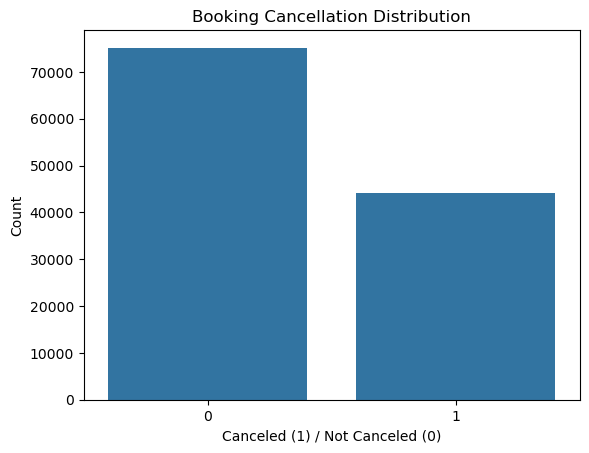

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='is_canceled', data=df)
plt.title("Booking Cancellation Distribution")
plt.xlabel("Canceled (1) / Not Canceled (0)")
plt.ylabel("Count")
plt.show()

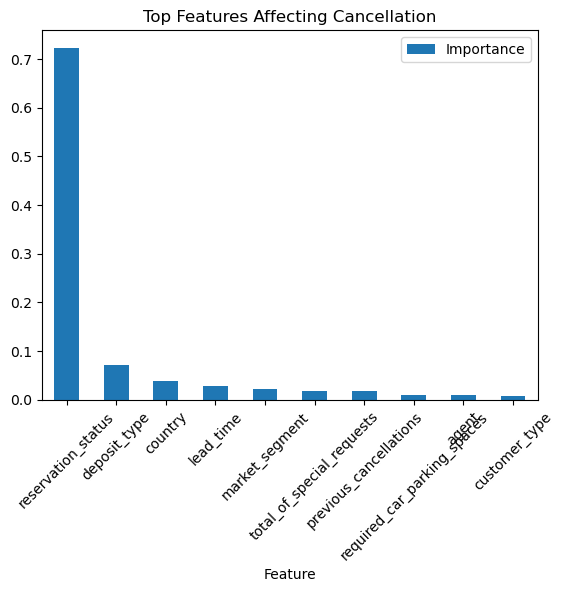

In [37]:
feature_importance.head(10).plot(
    x='Feature', y='Importance', kind='bar'
)
plt.title("Top Features Affecting Cancellation")
plt.xticks(rotation=45)
plt.show()

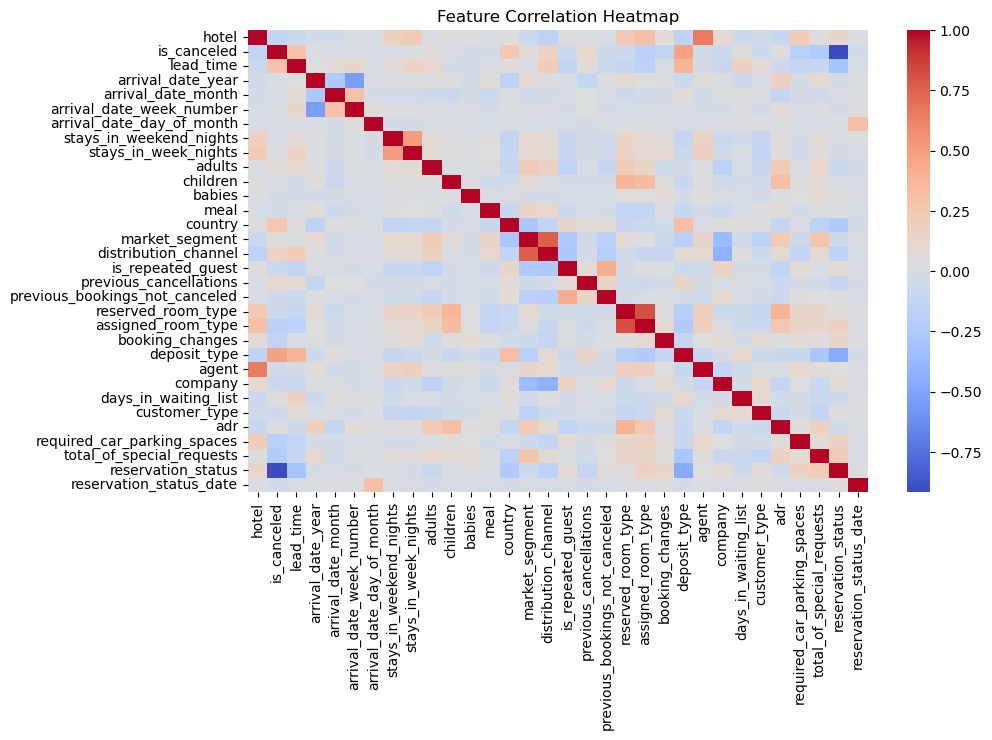

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

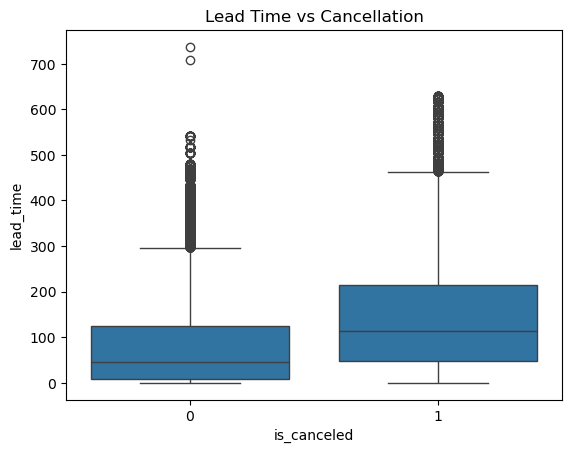

In [39]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time vs Cancellation")
plt.show()

## Question 01

### Problem:
Model achieves 99% training accuracy but only 74% testing accuracy.

### Explanation:
This indicates **Overfitting**.

The model has learned the training data too well, including noise and patterns that do not generalize to unseen data.

### Reasons:
- Model too complex (e.g., deep trees)
- Small or noisy dataset
- Lack of regularization
- Data leakage
- Imbalanced dataset

### Solutions to Improve Generalization:

1. **Use Cross Validation**
   - Helps evaluate model performance more reliably

2. **Reduce Model Complexity**
   - Limit tree depth in Random Forest

3. **Regularization Techniques**
   - Apply penalties to avoid overfitting

4. **Feature Selection**
   - Remove irrelevant or redundant features

5. **More Data**
   - Improves learning and reduces overfitting

6. **Data Augmentation**
   - Especially useful in large datasets

7. **Early Stopping**
   - Stop training when performance degrades

8. **Hyperparameter Tuning**
   - Optimize parameters like max_depth, n_estimators

### Conclusion:
The gap between training and testing accuracy clearly shows overfitting, and applying the above techniques will improve model generalization.

## Question 02

### Problem:
Dataset grows to 50 million records.

### Solution: Scalable ML Pipeline

### 1. Data Storage
- Use distributed storage like:
  - Hadoop (HDFS)
  - Cloud (AWS S3)

### 2. Data Processing
- Use:
  - Apache Spark
  - Dask

These tools process data in parallel → faster execution

### 3. Data Cleaning & Feature Engineering
- Perform using Spark DataFrames
- Avoid loading full data into memory

### 4. Model Training
- Use distributed ML libraries:
  - Spark MLlib
  - XGBoost (parallel)

### 5. Sampling Techniques
- Use subset of data for quick experimentation

### 6. Efficient Algorithms
- Prefer scalable models:
  - Logistic Regression
  - Gradient Boosting

### 7. Hardware Optimization
- Use:
  - GPUs
  - Cloud computing

### 8. Pipeline Automation
- Use tools like:
  - Airflow
  - MLflow

### 9. Model Evaluation
- Use distributed validation
- Avoid full dataset evaluation every time

### 10. Caching & Memory Optimization
- Cache frequently used data
- Use columnar formats (Parquet)

### Conclusion:
By using distributed computing, efficient algorithms, and optimized pipelines, we can handle large-scale datasets while minimizing execution time and cost.

##  Overall Conclusion
In this project, we successfully built an end-to-end machine learning pipeline to predict hotel booking cancellations.
We performed data preprocessing, feature engineering, model training, hyperparameter tuning, and evaluation.
The model achieved good performance and provided useful business insights that can help hotels reduce cancellations and improve decision-making.
This project demonstrates the practical application of machine learning in solving real-world business problems.